<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Global_EV_Charging_Station_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d tarekmasryo/global-ev-charging-stations

# Unziping the downloaded file
!unzip global-ev-charging-stations.zip

Saving kaggle.json to kaggle (2).json
Dataset URL: https://www.kaggle.com/datasets/tarekmasryo/global-ev-charging-stations
License(s): Attribution 4.0 International (CC BY 4.0)
global-ev-charging-stations.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  global-ev-charging-stations.zip
replace charging_stations_2025_world.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: charging_stations_2025_world.csv  
replace country_summary_2025.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: country_summary_2025.csv  
replace ev_models_2025.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: ev_models_2025.csv      
replace world_summary_2025.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: world_summary_2025.csv  


# Merging all the csv

In [4]:
df_1 = pd.read_csv('charging_stations_2025_world.csv')
df_2 = pd.read_csv('country_summary_2025.csv')
df_3 = pd.read_csv('ev_models_2025.csv')
df_4 = pd.read_csv('world_summary_2025.csv')

In [5]:
df = pd.concat([df_1, df_2, df_3, df_4], axis=1)
df.head(11)

,id,name,city,country_code,state_province,latitude,longitude,ports,power_kw,power_class,...,model,market_regions,powertrain,first_year,body_style,origin_country,country_code,country,count,max_power_kw_max
0,307660,Av. de Tarragona,Andorra,AD,NaN,42.505254,1.528861,10,300.0,DC_ULTRA_(>=150kW),...,Model S,Global (US/EU/UK/ME),BEV,2012.0,Sedan,US,US,United States,83821.0,600.0
1,301207,Parquing Costa Rodona,Encamp,AD,NaN,42.537213,1.727014,10,22.0,AC_HIGH_(22-49kW),...,Model 3,Global (US/EU/UK/ME/CN),BEV,2017.0,Sedan,US,GB,United Kingdom,27437.0,560.0
2,301206,Hotel Naudi,NaN,AD,NaN,42.576811,1.666061,1,11.0,AC_L2_(7.5-21kW),...,Model X,Global (US/EU/UK/ME),BEV,2015.0,SUV,US,DE,Germany,24465.0,400.0
3,301205,Hotel Piolets Soldeu Centre,NaN,AD,NaN,42.576466,1.667317,1,22.0,AC_HIGH_(22-49kW),...,Model Y,Global (US/EU/UK/ME/CN),BEV,2020.0,SUV,US,CA,Canada,18203.0,400.0
4,301204,Hotel Serras,NaN,AD,NaN,42.579458,1.659215,3,11.0,AC_L2_(7.5-21kW),...,Cybertruck,US (limited),BEV,2023.0,Pickup,US,ES,Spain,17864.0,1000.0
5,301203,HOTEL LLOP GRIS,NaN,AD,NaN,42.578070,1.648820,2,22.0,AC_HIGH_(22-49kW),...,Leaf,Global (EU/UK/US/JP),BEV,2010.0,Hatchback,JP,FR,France,13837.0,400.0
6,301202,Aparcament font del ferro,NaN,AD,NaN,42.582570,1.636854,3,11.0,AC_L2_(7.5-21kW),...,Bolt EV,US/CA (discontinued 2023; returning),BEV,2016.0,Hatchback,US,IT,Italy,10376.0,500.0
7,301201,Hotel l'Ermita,NaN,AD,NaN,42.554031,1.589863,1,11.0,AC_L2_(7.5-21kW),...,Bolt EUV,US/CA (discontinued 2023),BEV,2021.0,Crossover,US,NL,Netherlands,8111.0,501.0
8,301200,Restaurante Hotel Les Pardines,Encamp,AD,NaN,42.530853,1.600491,1,11.0,AC_L2_(7.5-21kW),...,Mustang Mach-E,US/EU/UK/ME,BEV,2020.0,SUV,US,SE,Sweden,4962.0,500.0
9,301199,La Solana Apartaments & Spa,Encamp,AD,NaN,42.534027,1.588139,1,7.4,AC_L1_(<7.5kW),...,F-150 Lightning,US/CA,BEV,2022.0,Pickup,US,NO,Norway,4794.0,350.0


In [7]:
df.tail(11)

,id,name,city,country_code,state_province,latitude,longitude,ports,power_kw,power_class,...,model,market_regions,powertrain,first_year,body_style,origin_country,country_code,country,count,max_power_kw_max
242406,147898,BP Buffelsjagrivier / Oude Post Bistro. off N2...,Swellendam Local Municipality,ZA,Overberg District Municipality,-34.038978,20.546043,1,30.0,AC_HIGH_(22-49kW),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
242407,147845,Caltex Fresh Stop Caledon,Caledon,ZA,Western Cape,-34.224859,19.436632,2,60.0,DC_FAST_(50-149kW),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
242408,134508,Gardens Centre,Cape Town,ZA,City of Cape Town,-33.934538,18.417932,2,50.0,DC_FAST_(50-149kW),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
242409,134507,Stellenbosch Square parking,Stellenbosch Local Municipality,ZA,Cape Winelands District Municipality,-33.976782,18.843214,1,50.0,DC_FAST_(50-149kW),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
242410,132798,Hype Park Corner Shopping Centre,Sandton,ZA,Guateng,-26.125892,28.033167,2,22.0,AC_HIGH_(22-49kW),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
242411,105474,Breakwater Boulevard,Cape Town,ZA,Western Cape,-33.902096,18.421160,2,7.0,AC_L1_(<7.5kW),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
242412,105286,Pick 'n Pay,Cape Town,ZA,City of Cape Town,-33.903020,18.419719,2,7.0,AC_L1_(<7.5kW),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
242413,79380,BMW Cedar Isle Auto,Fourways,ZA,Gauteng,-26.020846,28.001618,1,125.0,DC_FAST_(50-149kW),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
242414,23789,Melrose Nissan,Johannesburg,ZA,NaN,-26.129126,28.068905,1,NaN,UNKNOWN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
242415,23657,Nissan Mcarthy Randburg,Randburg,ZA,Gauteng,-26.088826,27.982802,1,NaN,UNKNOWN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# Replace with the actual column names you want to select
selected_columns = ['id', 'name', 'city','country', 'ports', 'power_class', 'longitude','count','max_power_kw_max','model']

dff = df[selected_columns]

# Display the first few rows of the new DataFrame
display(dff.head())

,id,name,city,country,ports,power_class,longitude,count,max_power_kw_max,model
0,307660,Av. de Tarragona,Andorra,United States,10,DC_ULTRA_(>=150kW),1.528861,83821.0,600.0,Model S
1,301207,Parquing Costa Rodona,Encamp,United Kingdom,10,AC_HIGH_(22-49kW),1.727014,27437.0,560.0,Model 3
2,301206,Hotel Naudi,NaN,Germany,1,AC_L2_(7.5-21kW),1.666061,24465.0,400.0,Model X
3,301205,Hotel Piolets Soldeu Centre,NaN,Canada,1,AC_HIGH_(22-49kW),1.667317,18203.0,400.0,Model Y
4,301204,Hotel Serras,NaN,Spain,3,AC_L2_(7.5-21kW),1.659215,17864.0,1000.0,Cybertruck


In [9]:
dff.shape

(242417, 10)

In [10]:
dff.columns

Index(['id', 'name', 'city', 'country', 'ports', 'power_class', 'longitude',
       'count', 'max_power_kw_max', 'model'],
      dtype='object')

In [11]:
dff.dtypes

,0
id,int64
name,object
city,object
country,object
ports,int64
power_class,object
longitude,float64
count,float64
max_power_kw_max,float64
model,object


In [12]:
dff.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242417 entries, 0 to 242416
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                242417 non-null  int64  
 1   name              242417 non-null  object 
 2   city              220228 non-null  object 
 3   country           122 non-null     object 
 4   ports             242417 non-null  int64  
 5   power_class       242417 non-null  object 
 6   longitude         242417 non-null  float64
 7   count             122 non-null     float64
 8   max_power_kw_max  118 non-null     float64
 9   model             63 non-null      object 
dtypes: float64(3), int64(2), object(5)
memory usage: 18.5+ MB


In [13]:
dff.describe(include = 'all')

,id,name,city,country,ports,power_class,longitude,count,max_power_kw_max,model
count,242417.000000,242417,220228,122,242417.000000,242417,242417.000000,122.000000,118.000000,63
unique,NaN,225282,41815,122,NaN,6,NaN,NaN,NaN,63
top,NaN,Shell Recharge/Ubitricity,London,United States,NaN,AC_L1_(<7.5kW),NaN,NaN,NaN,Model S
freq,NaN,1166,7665,1,NaN,107144,NaN,NaN,NaN,1
mean,204039.926519,NaN,NaN,NaN,1.959277,NaN,-32.074160,2035.204918,8710.432203,NaN
std,101789.186799,NaN,NaN,NaN,3.931007,NaN,57.652645,8616.963391,92035.801103,NaN
min,2389.000000,NaN,NaN,NaN,-4.000000,NaN,-164.848855,1.000000,7.000000,NaN
25%,122882.000000,NaN,NaN,NaN,1.000000,NaN,-81.644018,5.250000,72.750000,NaN
50%,208085.000000,NaN,NaN,NaN,1.000000,NaN,-2.867264,57.000000,180.000000,NaN
75%,280795.000000,NaN,NaN,NaN,2.000000,NaN,7.883693,564.000000,357.500000,NaN


In [14]:
dff.isnull().sum()

,0
id,0
name,0
city,22189
country,242295
ports,0
power_class,0
longitude,0
count,242295
max_power_kw_max,242299
model,242354


In [15]:
# Identify numerical and categorical columns in dff
numerical_cols_dff = dff.select_dtypes(include=np.number).columns
categorical_cols_dff = dff.select_dtypes(include='object').columns

# For numerical columns, we might impute with the mean or median
for col in numerical_cols_dff:
    if dff[col].isnull().any():
        dff[col].fillna(dff[col].mean(), inplace=True)

# For categorical columns, we might impute with the mode or a constant
for col in categorical_cols_dff:
    if dff[col].isnull().any():
        dff[col].fillna(dff[col].mode()[0], inplace=True)

dff.isnull().sum()

,0
id,0
name,0
city,0
country,0
ports,0
power_class,0
longitude,0
count,0
max_power_kw_max,0
model,0


# Handling Outliers

In [16]:
Q1 = dff['max_power_kw_max'].quantile(0.25)
Q3 = dff['max_power_kw_max'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_Outliers = dff[(dff['max_power_kw_max'] >= lower_bound) | (dff['max_power_kw_max'] <= upper_bound)].copy()

print(f'Original Shape: {len(dff)}')
print(f'Shape after outlier handling: {len(df_Outliers)}')

Original Shape: 242417
Shape after outlier handling: 242417


# Univariate Analysis

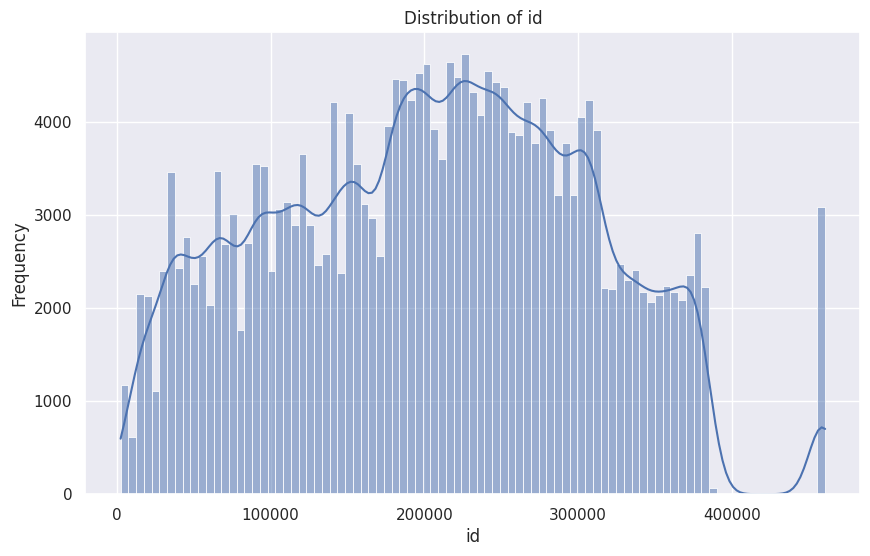

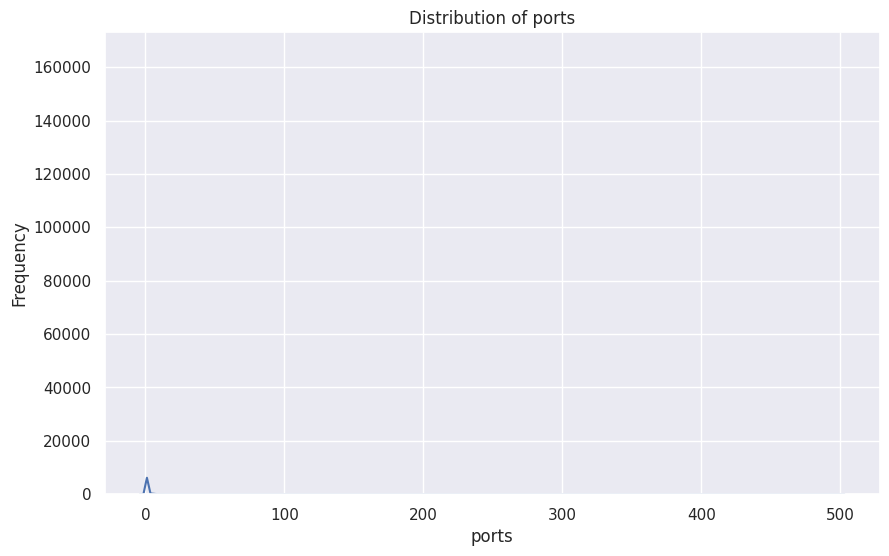

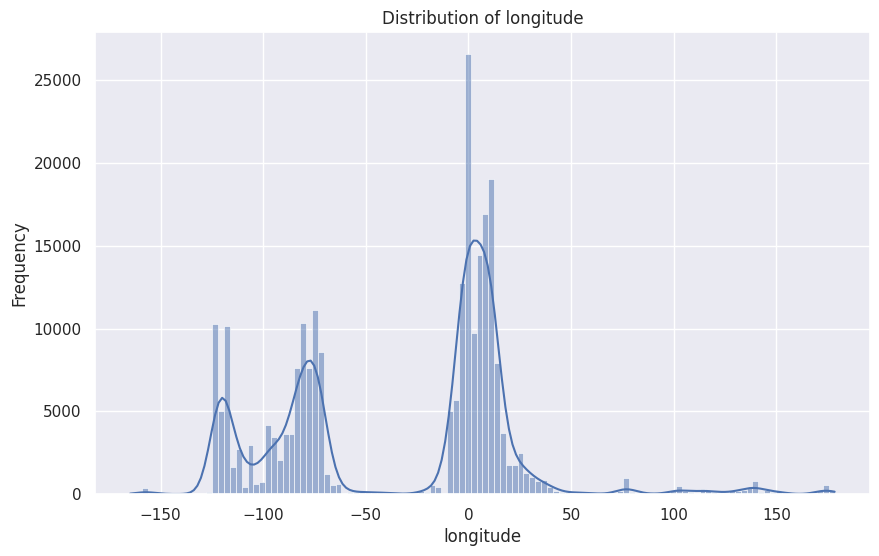

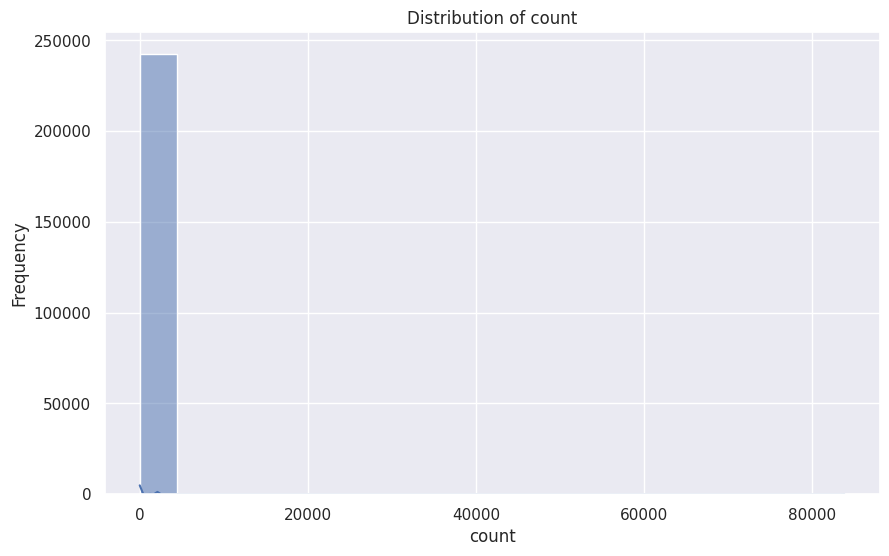

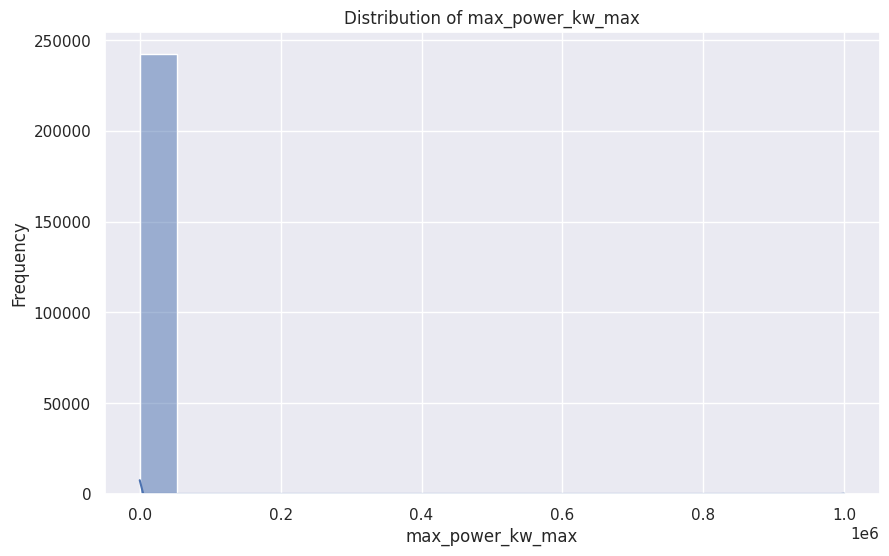

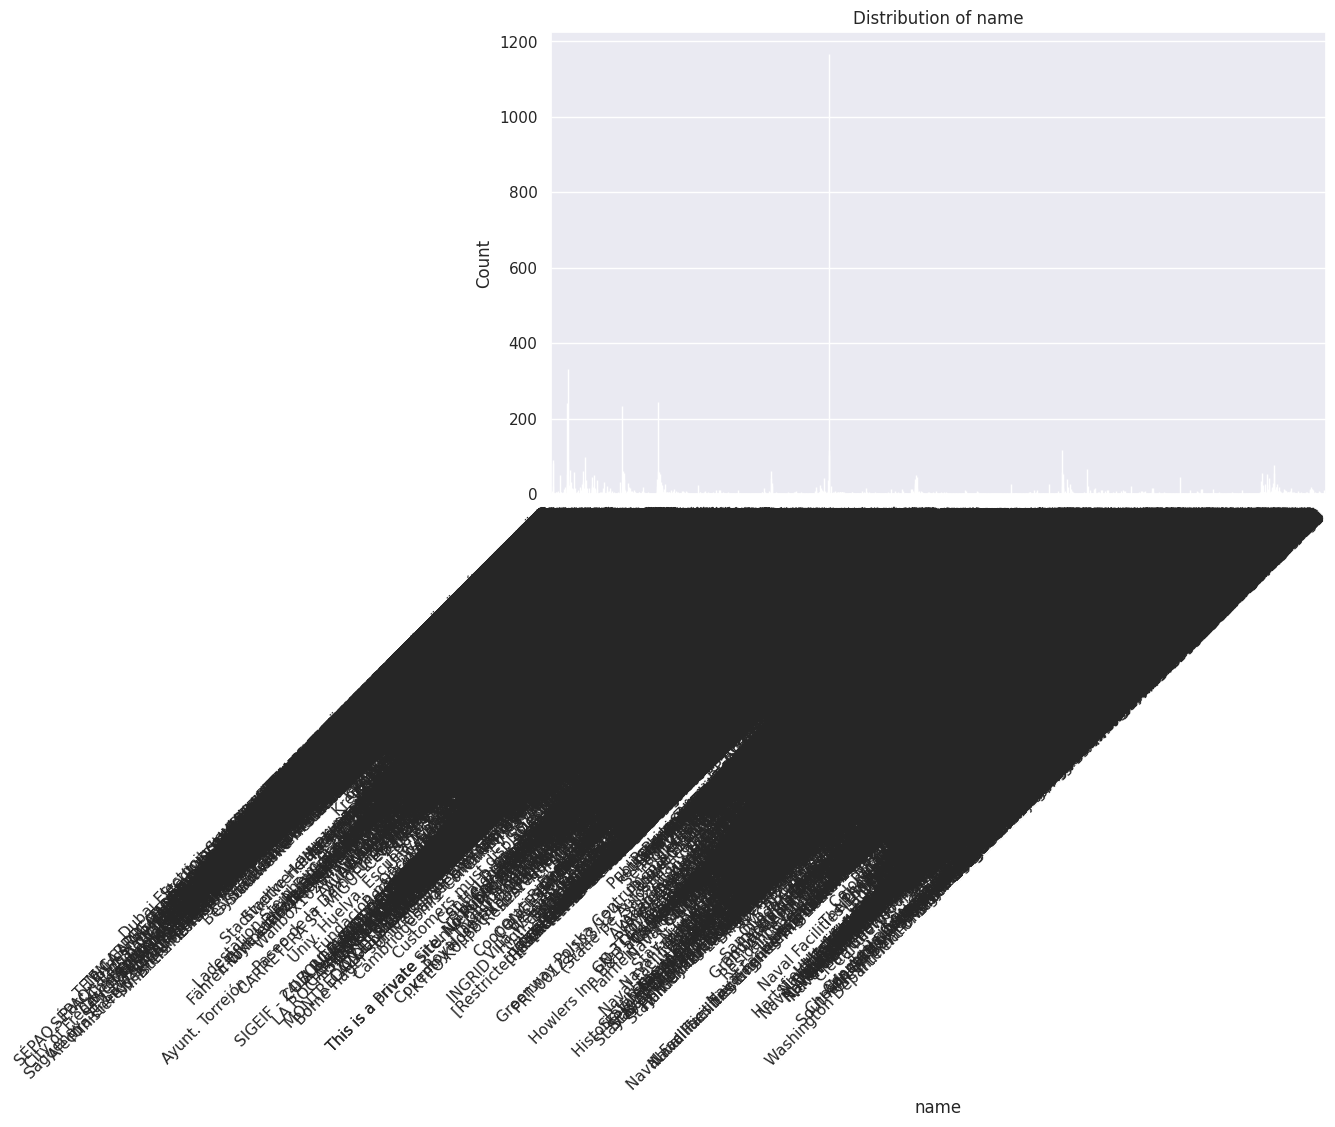

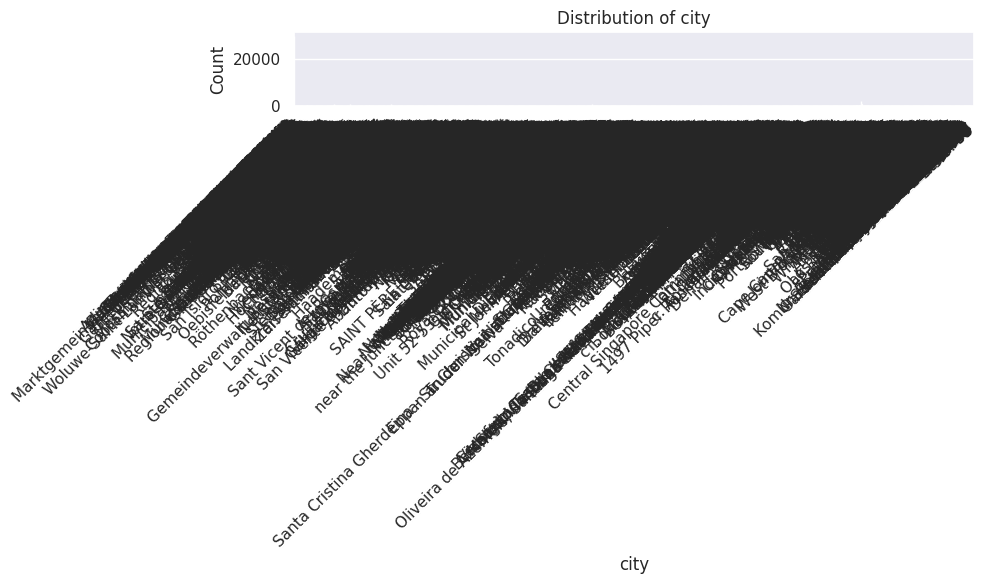

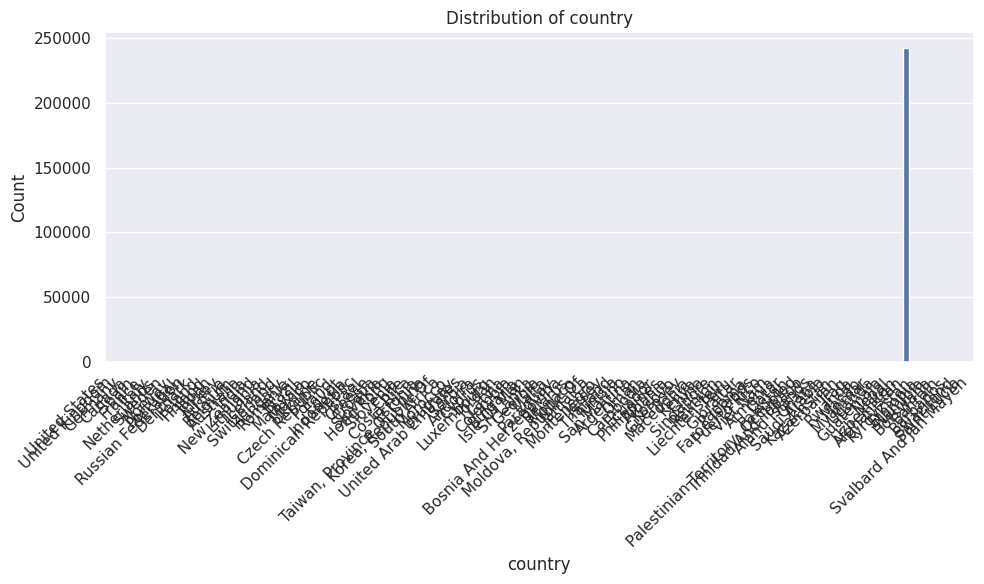

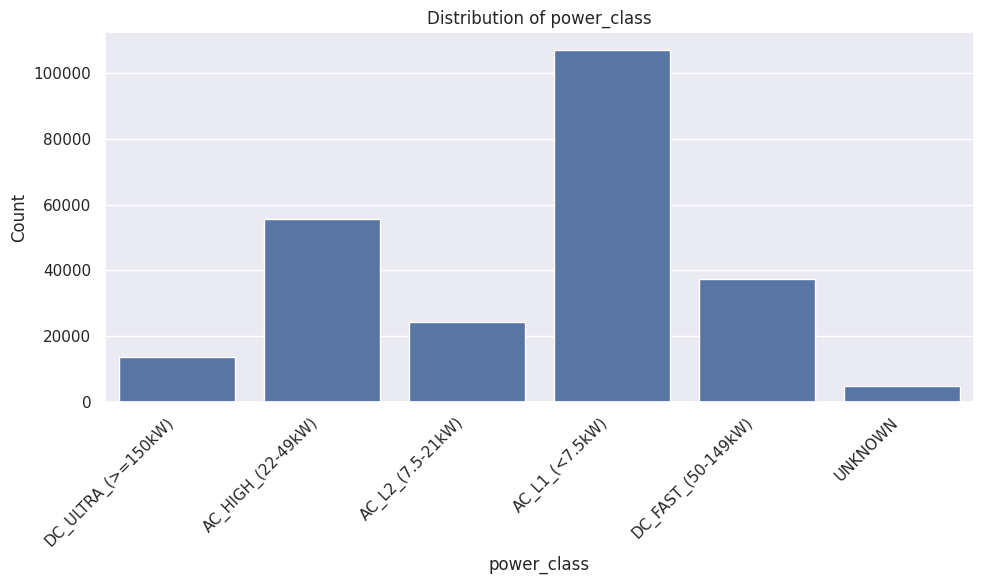

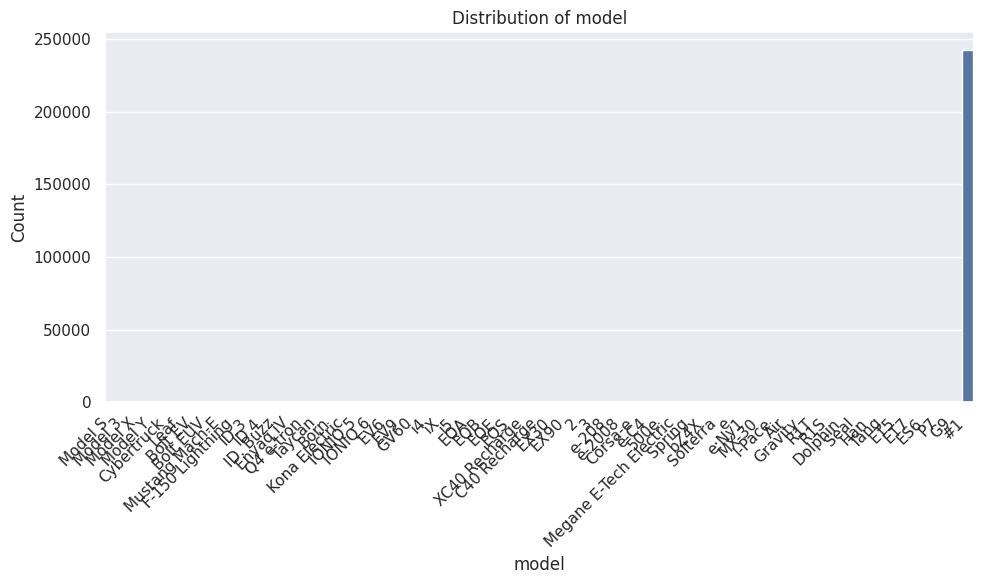

Value counts for name:
name
Shell Recharge/Ubitricity         1166
SWTCH Energy Inc.                  331
Rathaus                            244
Swtch Energy                       242
Comfortcharge Ladestation          234
                                  ... 
Renault Retail Group Le Havre        1
Centre Leclerc                       1
Centre E.Leclerc - Le Neubourg       1
Leclerc - Menneval                   1
Arcaade                              1
Name: count, Length: 225282, dtype: int64

Value counts for city:
city
London              29854
Los Angeles          2128
Hammersmith          1118
Montréal              991
Berlin                827
                    ...  
Mooi Rivier             1
Pietermaritzburg        1
East London             1
Port Elizabeth          1
Graaff-Reinet           1
Name: count, Length: 41815, dtype: int64

Value counts for country:
country
Afghanistan               242296
United States                  1
Germany                        1
Canada     

In [17]:
# Getting a list of numerical columns
numerical_cols = dff.select_dtypes(include=np.number).columns.tolist()

# Iterate through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=dff, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = dff.select_dtypes(include='object').columns.tolist()

# Iterating through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=dff, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Here we can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{dff[col].value_counts()}\n")

# Bivariate Analysis

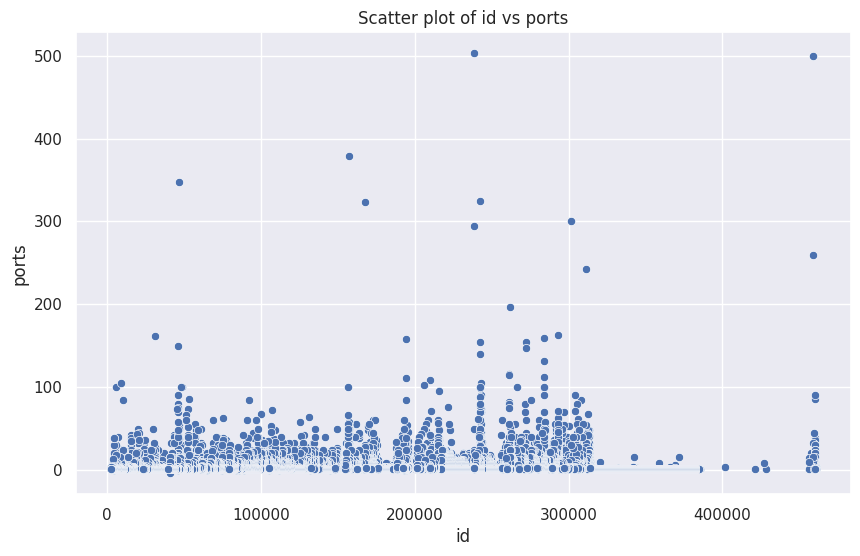

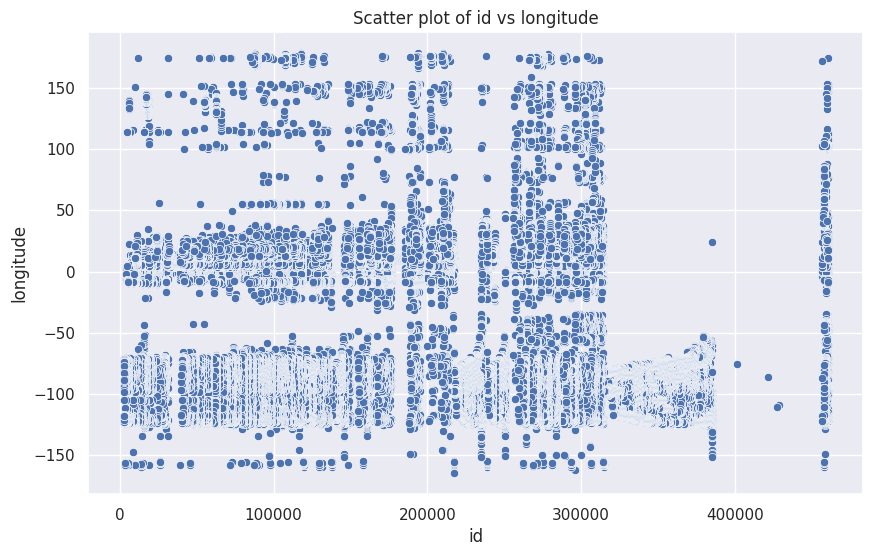

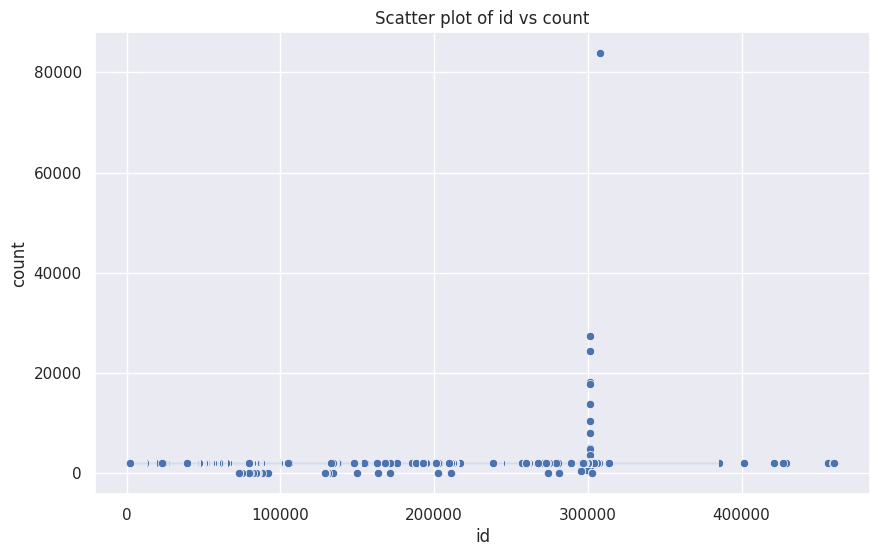

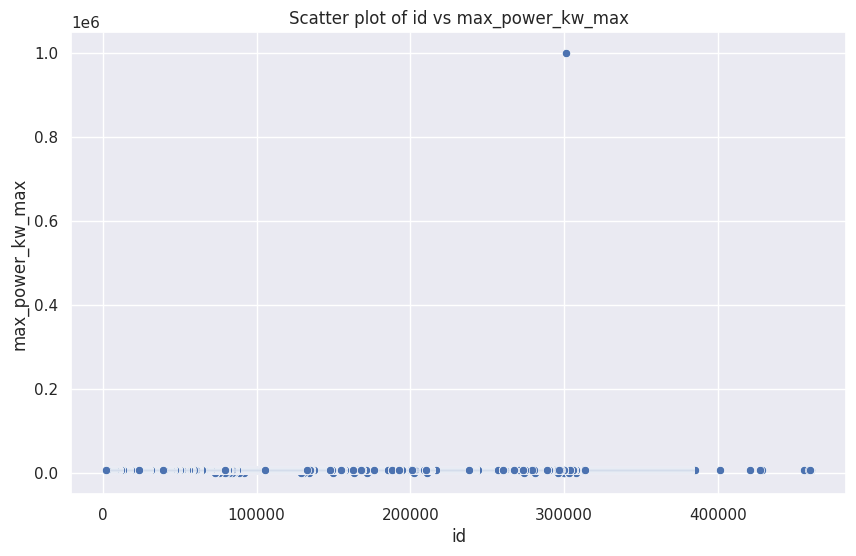

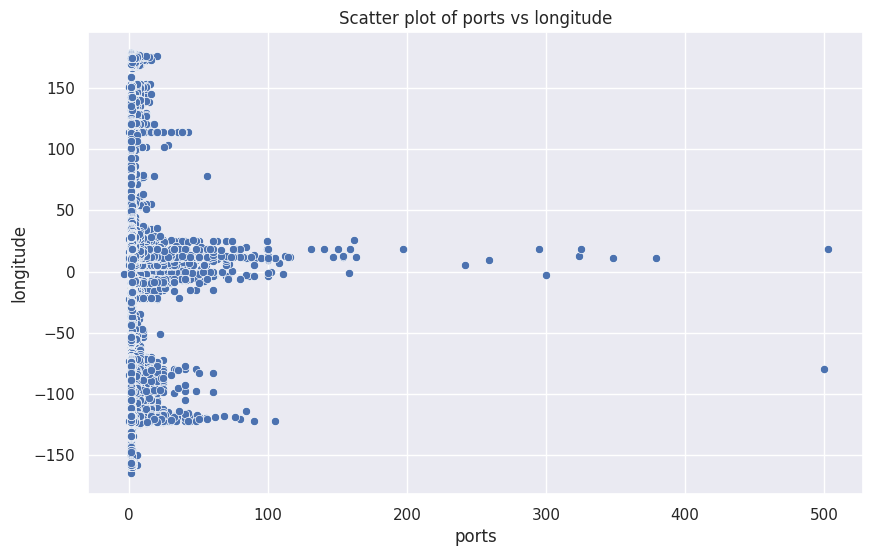

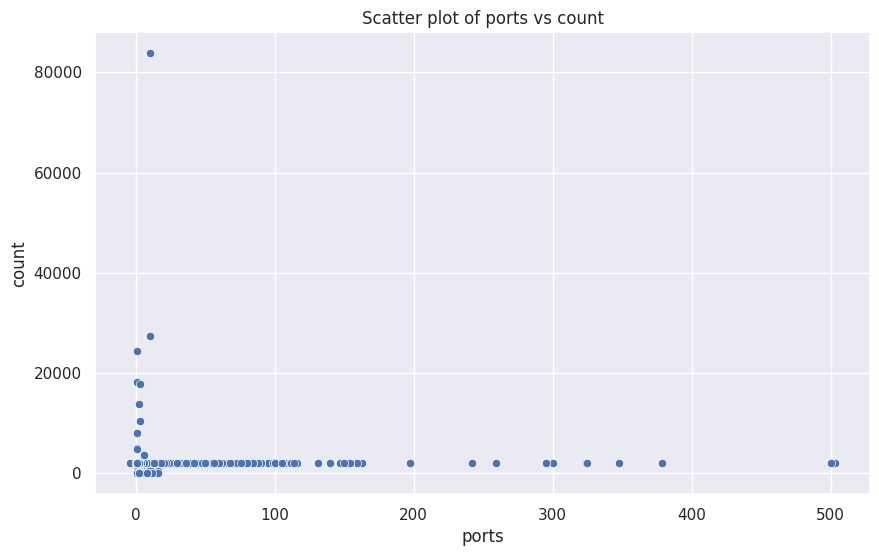

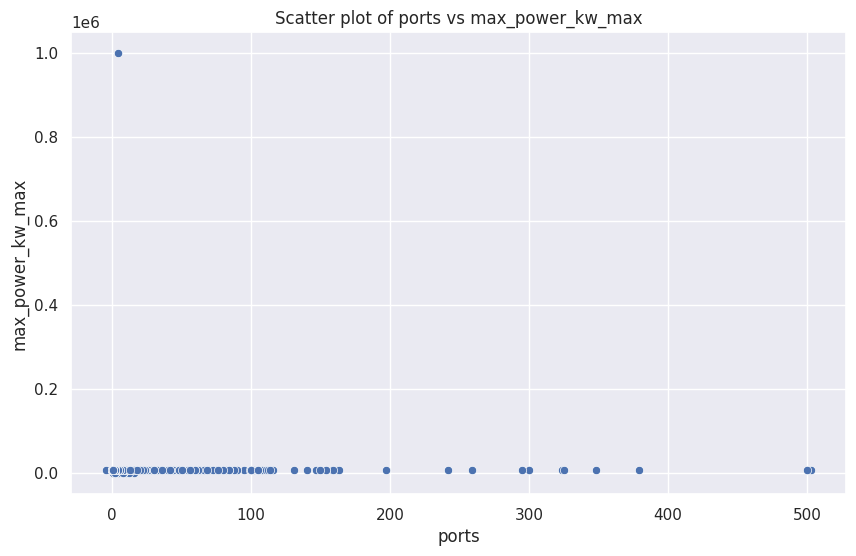

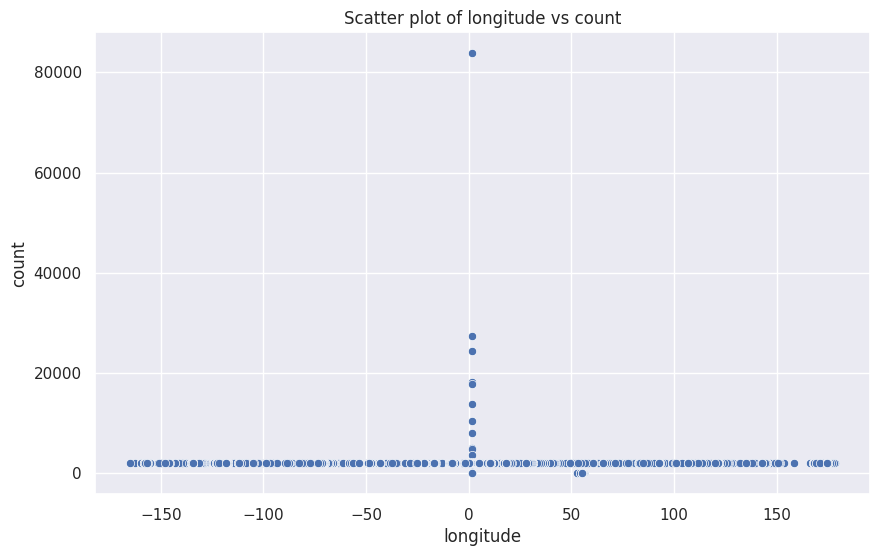

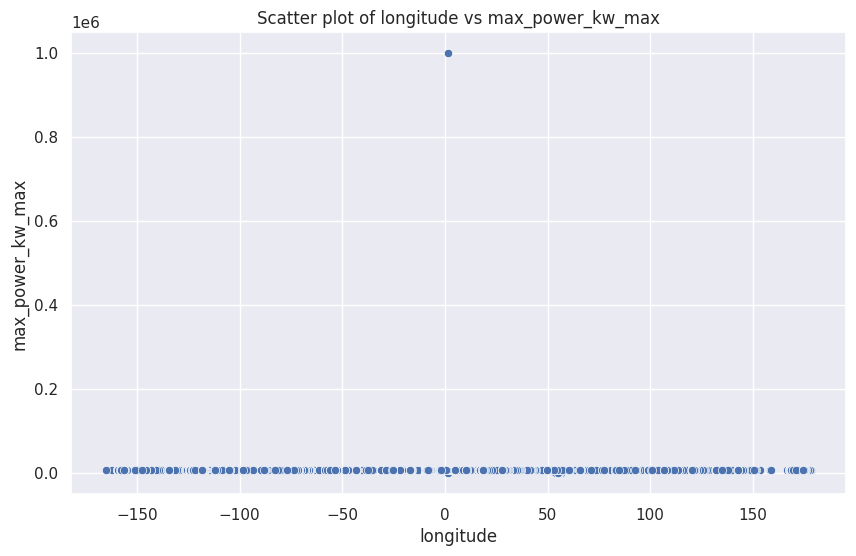

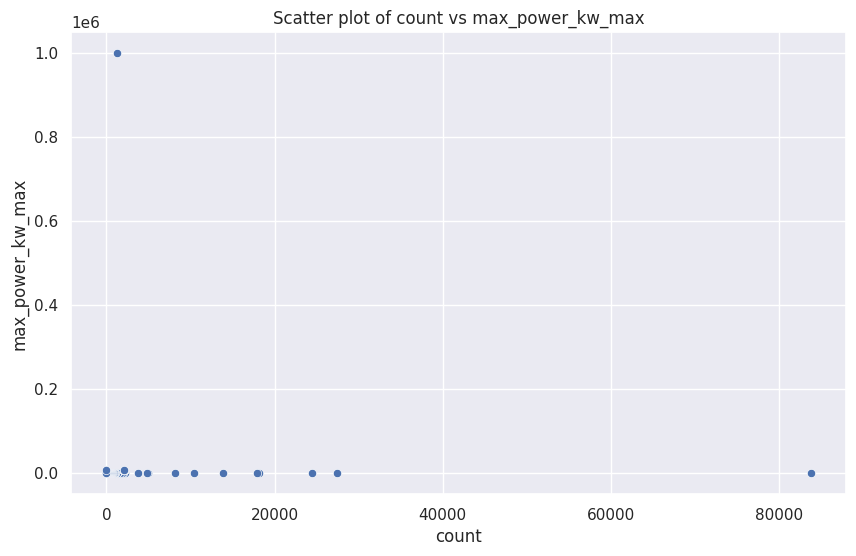

In [ ]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = dff.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=dff, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = dff.select_dtypes(include='object').columns.tolist()
numerical_cols = dff.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=dff, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

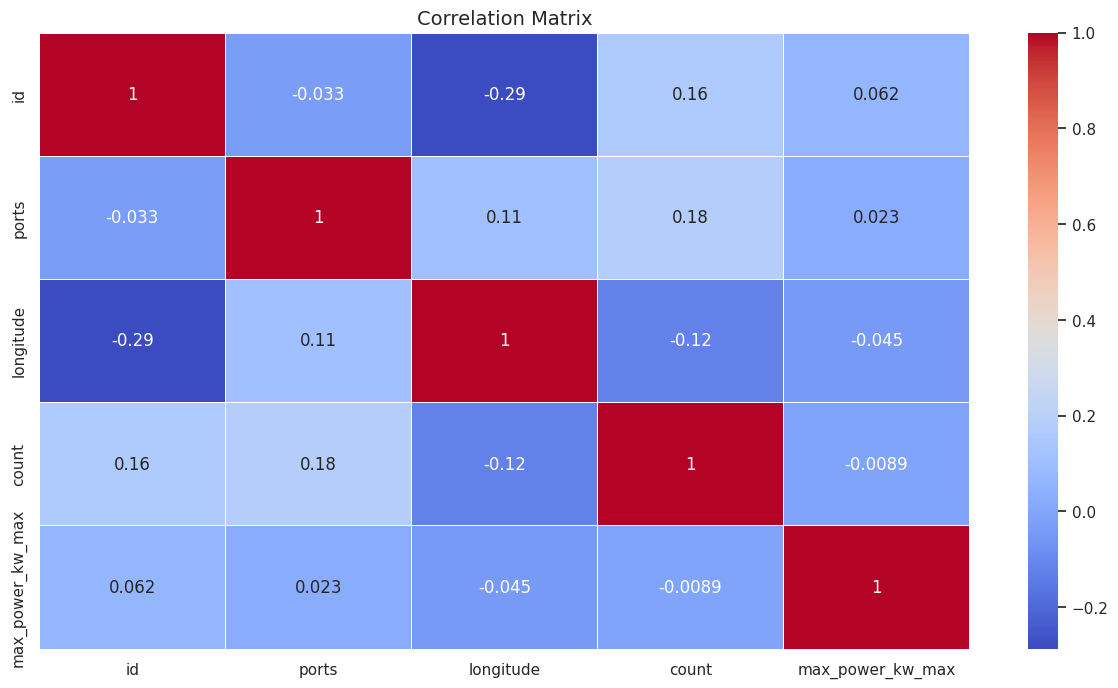

In [9]:
plt.figure(figsize=(15, 8))
sns.heatmap(dff.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank you